In [ ]:
print("omkar")

In [1]:
print("omkar")

omkar


In [3]:
pip install pandas numpy scipy scikit-learn matplotlib seaborn jupyter

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42

np.random.seed(SEED)

print("Setup complete")

Setup complete


In [3]:
DATA_PATH = Path("data/ml-100k/u.data")

ratings = pd.read_csv(
    DATA_PATH,
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
print("Shape:", ratings.shape)
print("\nColumns:")
print(ratings.columns.tolist())

print("\nMissing values:")
print(ratings.isnull().sum())

print("\nDuplicates:", ratings.duplicated().sum())


Shape: (100000, 4)

Columns:
['user_id', 'item_id', 'rating', 'timestamp']

Missing values:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

Duplicates: 0


In [5]:
ratings.describe()

,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


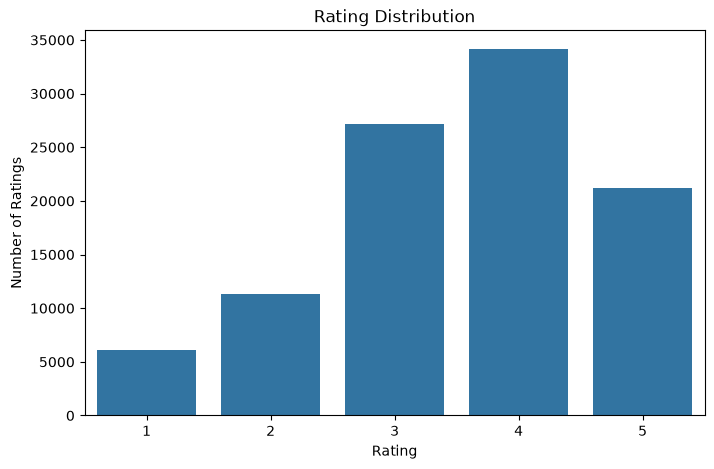

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=ratings,
    x="rating"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

In [7]:
print("Unique users:", ratings["user_id"].nunique())
print("Unique items:", ratings["item_id"].nunique())
print("Total ratings:", len(ratings))

Unique users: 943
Unique items: 1682
Total ratings: 100000


In [8]:
user_counts = ratings.groupby("user_id").size()

print(user_counts.describe())


count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64


In [9]:
train_val, test = train_test_split(
    ratings,
    test_size=0.15,
    random_state=SEED
)

train, val = train_test_split(
    train_val,
    test_size=0.15 / 0.85,
    random_state=SEED
)

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (69999, 4)
Validation: (15001, 4)
Test: (15000, 4)


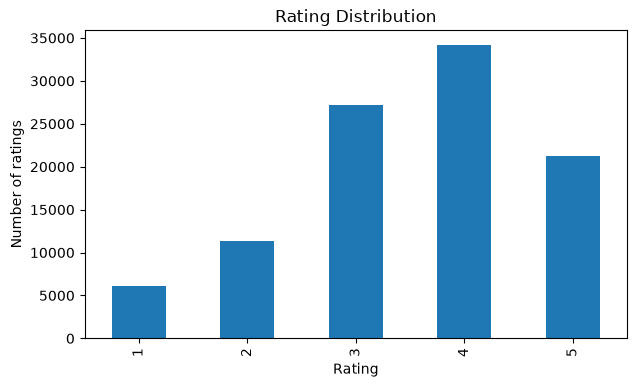

In [10]:
ratings["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("Rating Distribution")
plt.show()

In [11]:
n_users = ratings["user_id"].nunique()
n_items = ratings["item_id"].nunique()
n_ratings = len(ratings)

total_possible = n_users * n_items

density = n_ratings / total_possible
sparsity = 1 - density

print(f"Possible user-item pairs: {total_possible:,}")
print(f"Observed ratings: {n_ratings:,}")
print(f"Density: {density:.4%}")
print(f"Sparsity: {sparsity:.4%}")

Possible user-item pairs: 1,586,126
Observed ratings: 100,000
Density: 6.3047%
Sparsity: 93.6953%


In [12]:
user_counts = ratings.groupby("user_id").size()
item_counts = ratings.groupby("item_id").size()

print("Ratings per user:")
print(user_counts.describe())

print("\nRatings per item:")
print(item_counts.describe())

Ratings per user:
count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64

Ratings per item:
count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
dtype: float64


In [15]:
print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print("\nTotal:", len(train) + len(val) + len(test))
print("Original:", len(ratings))

print("\nUsers:")
print("Train:", train["user_id"].nunique())
print("Validation:", val["user_id"].nunique())
print("Test:", test["user_id"].nunique())

print("\nItems:")
print("Train:", train["item_id"].nunique())
print("Validation:", val["item_id"].nunique())
print("Test:", test["item_id"].nunique())

Train: (69999, 4)
Validation: (15001, 4)
Test: (15000, 4)

Total: 100000
Original: 100000

Users:
Train: 943
Validation: 943
Test: 935

Items:
Train: 1638
Validation: 1357
Test: 1353


In [16]:
random_train = train.copy()
random_val = val.copy()
random_test = test.copy()

In [17]:
# Unique users/items from training data
users = np.sort(train["user_id"].unique())
items = np.sort(train["item_id"].unique())

user_to_idx = {user: idx for idx, user in enumerate(users)}
item_to_idx = {item: idx for idx, item in enumerate(items)}

idx_to_user = {idx: user for user, idx in user_to_idx.items()}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

print("Users:", len(users))
print("Items:", len(items))

Users: 943
Items: 1638


In [19]:
user_item_matrix = np.zeros(
    (len(users), len(items)),
    dtype=np.float32
)

for row in train.itertuples(index=False):
    u = user_to_idx[row.user_id]
    i = item_to_idx[row.item_id]

    user_item_matrix[u, i] = row.rating

print("Matrix shape:", user_item_matrix.shape)

Matrix shape: (943, 1638)


In [20]:
print("Non-zero entries:", np.count_nonzero(user_item_matrix))

expected = len(train)

print("Training ratings:", expected)
print(
    "Matrix contains all training ratings:",
    np.count_nonzero(user_item_matrix) == expected
)

Non-zero entries: 69999
Training ratings: 69999
Matrix contains all training ratings: True


In [21]:
matrix_density = np.count_nonzero(user_item_matrix) / user_item_matrix.size
matrix_sparsity = 1 - matrix_density

print(f"Density: {matrix_density:.4%}")
print(f"Sparsity: {matrix_sparsity:.4%}")

Density: 4.5318%
Sparsity: 95.4682%


In [22]:
#cosine similarity(A,B) =(A · B) / (||A|| ||B||)

from sklearn.metrics.pairwise import cosine_similarity

# Items × Users
item_user_matrix = user_item_matrix.T

print("Item-user matrix:", item_user_matrix.shape)

# Item-item cosine similarity
item_similarity = cosine_similarity(item_user_matrix)

print("Similarity matrix:", item_similarity.shape)

Item-user matrix: (1638, 943)
Similarity matrix: (1638, 1638)


In [24]:
print("Min similarity:", item_similarity.min())
print("Max similarity:", item_similarity.max())

# Similarity of an item with itself
print("Diagonal sample:", item_similarity.diagonal()[:10])

Min similarity: 0.0
Max similarity: 1.000001
Diagonal sample: [0.99999994 1.0000001  0.9999998  1.0000004  0.99999994 1.0000001
 0.99999946 1.0000002  1.0000001  0.9999999 ]


In [28]:
#                 Σ similarity(i,j) × rating(u,j)
#prediction(i) = ─────────────────────────────────
#                 Σ |similarity(i,j)|


def predict_rating_item_cf(
    user_id,
    item_id,
    user_item_matrix,
    user_to_idx,
    item_to_idx,
    item_similarity,
    k=20
):
    if user_id not in user_to_idx or item_id not in item_to_idx:
        return np.nan

    user_idx = user_to_idx[user_id]
    item_idx = item_to_idx[item_id]

    user_ratings = user_item_matrix[user_idx]

    # Items the user has rated
    rated_items = np.flatnonzero(user_ratings)

    if len(rated_items) == 0:
        return np.nan

    # Similarities between target item and user's rated items
    similarities = item_similarity[item_idx, rated_items]

    # Select top-k similar rated items
    k = min(k, len(rated_items))

    top_k_indices = np.argsort(similarities)[-k:]

    selected_items = rated_items[top_k_indices]
    selected_similarities = similarities[top_k_indices]
    selected_ratings = user_ratings[selected_items]

    denominator = np.sum(np.abs(selected_similarities))

    if denominator == 0:
        return np.nan

    prediction = np.sum(
        selected_similarities * selected_ratings
    ) / denominator

    prediction = np.clip(prediction, 1.0, 5.0)

    return prediction

In [26]:
sample_user = train.iloc[0]["user_id"]
sample_item = train.iloc[0]["item_id"]

pred = predict_rating_item_cf(
    sample_user,
    sample_item,
    user_item_matrix,
    user_to_idx,
    item_to_idx,
    item_similarity,
    k=20
)

print("User:", sample_user)
print("Item:", sample_item)
print("Predicted rating:", pred)

User: 406
Item: 134
Predicted rating: 4.210222


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_item_cf(data, k):
    actual = []
    predicted = []

    for row in data.itertuples(index=False):

        pred = predict_rating_item_cf(
            row.user_id,
            row.item_id,
            user_item_matrix,
            user_to_idx,
            item_to_idx,
            item_similarity,
            k=k
        )

        # Ignore cases the model cannot predict
        if not np.isnan(pred):
            actual.append(row.rating)
            predicted.append(pred)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    coverage = len(predicted) / len(data)

    return rmse, mae, coverage

In [31]:
k_values = [5, 10, 20, 40, 80,100,150,200]

results_cf = []

for k in k_values:

    rmse, mae, coverage = evaluate_item_cf(
        val,
        k
    )

    results_cf.append({
        "k": k,
        "RMSE": rmse,
        "MAE": mae,
        "Coverage": coverage
    })

    print(
        f"K={k:>2} | "
        f"RMSE={rmse:.4f} | "
        f"MAE={mae:.4f} | "
        f"Coverage={coverage:.4%}"
    )

K= 5 | RMSE=1.0019 | MAE=0.7770 | Coverage=99.8400%
K=10 | RMSE=0.9766 | MAE=0.7606 | Coverage=99.8400%
K=20 | RMSE=0.9793 | MAE=0.7656 | Coverage=99.8400%
K=40 | RMSE=0.9899 | MAE=0.7772 | Coverage=99.8400%
K=80 | RMSE=1.0040 | MAE=0.7935 | Coverage=99.8400%
K=100 | RMSE=1.0082 | MAE=0.7985 | Coverage=99.8400%
K=150 | RMSE=1.0134 | MAE=0.8053 | Coverage=99.8400%
K=200 | RMSE=1.0161 | MAE=0.8081 | Coverage=99.8400%


In [32]:
cf_results_df = pd.DataFrame(results_cf)

cf_results_df

,k,RMSE,MAE,Coverage
0,5,1.001872,0.776981,0.9984
1,10,0.976579,0.760558,0.9984
2,20,0.979329,0.765570,0.9984
3,40,0.989865,0.777203,0.9984
4,80,1.004015,0.793460,0.9984
5,100,1.008174,0.798546,0.9984
6,150,1.013450,0.805320,0.9984
7,200,1.016102,0.808091,0.9984


In [33]:
best_k = cf_results_df.loc[
    cf_results_df["RMSE"].idxmin(),
    "k"
]

print("Best K:", best_k)

Best K: 10


In [36]:
best_k = 10

test_rmse, test_mae, test_coverage = evaluate_item_cf(
    test,
    k=best_k
)

print(f"Best K: {best_k}")
print(f"Test RMSE: {test_rmse:.4%}")
print(f"Test MAE: {test_mae:.4%}")
print(f"Test Coverage: {test_coverage:.4%}")

item_cf_results = {
    "Model": "Item-Item Collaborative Filtering",
    "K": best_k,
    "Validation RMSE": cf_results_df.loc[
        cf_results_df["RMSE"].idxmin(), "RMSE"
    ],
    "Validation MAE": cf_results_df.loc[
        cf_results_df["RMSE"].idxmin(), "MAE"
    ],
    "Test RMSE": test_rmse,
    "Test MAE": test_mae,
    "Test Coverage": test_coverage
}

item_cf_results

Best K: 10
Test RMSE: 96.7356%
Test MAE: 75.5617%
Test Coverage: 99.8200%


{'Model': 'Item-Item Collaborative Filtering',
 'K': 10,
 'Validation RMSE': np.float64(0.9765789429390377),
 'Validation MAE': np.float64(0.760558143583439),
 'Test RMSE': np.float64(0.96735642392775),
 'Test MAE': 0.7556170913823292,
 'Test Coverage': 0.9982}

In [37]:
#R ≈ U × Vᵀ
#U = user latent factors
#V = item latent factors

mf_train = train[["user_id", "item_id", "rating"]].copy()

mf_train["user_idx"] = mf_train["user_id"].map(user_to_idx)
mf_train["item_idx"] = mf_train["item_id"].map(item_to_idx)

mf_train.head()

,user_id,item_id,rating,user_idx,item_idx
50482,406,134,5,405,133
2701,178,234,4,177,233
6237,130,228,4,129,227
55777,161,69,4,160,68
35621,615,886,2,614,884


In [38]:
print("Missing user indices:", mf_train["user_idx"].isna().sum())
print("Missing item indices:", mf_train["item_idx"].isna().sum())

Missing user indices: 0
Missing item indices: 0


In [39]:
class MatrixFactorization:
    def __init__(
        self,
        n_users,
        n_items,
        n_factors=20,
        learning_rate=0.005,
        reg=0.02,
        seed=42
    ):
        rng = np.random.default_rng(seed)

        self.n_users = n_users
        self.n_items = n_items
        self.n_factors = n_factors
        self.lr = learning_rate
        self.reg = reg

        # Small random initialization
        self.user_factors = rng.normal(
            0,
            0.1,
            size=(n_users, n_factors)
        )

        self.item_factors = rng.normal(
            0,
            0.1,
            size=(n_items, n_factors)
        )

        self.user_bias = np.zeros(n_users)
        self.item_bias = np.zeros(n_items)

        self.global_mean = 0.0

    def predict_idx(self, user_idx, item_idx):
        return (
            self.global_mean
            + self.user_bias[user_idx]
            + self.item_bias[item_idx]
            + np.dot(
                self.user_factors[user_idx],
                self.item_factors[item_idx]
            )
        )

    def predict(self, user_id, item_id, user_to_idx, item_to_idx):
        if user_id not in user_to_idx:
            return np.nan

        if item_id not in item_to_idx:
            return np.nan

        u = user_to_idx[user_id]
        i = item_to_idx[item_id]

        prediction = self.predict_idx(u, i)

        return np.clip(prediction, 1.0, 5.0)

    def fit(
        self,
        data,
        epochs=20,
        verbose=True
    ):
        self.global_mean = data["rating"].mean()

        history = []

        for epoch in range(epochs):
            total_squared_error = 0.0

            # Shuffle training examples every epoch
            shuffled = data.sample(
                frac=1,
                random_state=42 + epoch
            )

            for row in shuffled.itertuples(index=False):

                u = int(row.user_idx)
                i = int(row.item_idx)
                r = float(row.rating)

                prediction = self.predict_idx(u, i)

                error = r - prediction

                total_squared_error += error ** 2

                user_factor_old = self.user_factors[u].copy()

                # Bias updates
                self.user_bias[u] += self.lr * (
                    error - self.reg * self.user_bias[u]
                )

                self.item_bias[i] += self.lr * (
                    error - self.reg * self.item_bias[i]
                )

                # Factor updates
                self.user_factors[u] += self.lr * (
                    error * self.item_factors[i]
                    - self.reg * self.user_factors[u]
                )

                self.item_factors[i] += self.lr * (
                    error * user_factor_old
                    - self.reg * self.item_factors[i]
                )

            rmse = np.sqrt(
                total_squared_error / len(data)
            )

            history.append(rmse)

            if verbose:
                print(
                    f"Epoch {epoch + 1:2d}/{epochs} "
                    f"| Train RMSE: {rmse:.4f}"
                )

        return history

Epoch  1/20 | Train RMSE: 1.0548
Epoch  2/20 | Train RMSE: 0.9881
Epoch  3/20 | Train RMSE: 0.9632
Epoch  4/20 | Train RMSE: 0.9491
Epoch  5/20 | Train RMSE: 0.9395
Epoch  6/20 | Train RMSE: 0.9322
Epoch  7/20 | Train RMSE: 0.9263
Epoch  8/20 | Train RMSE: 0.9212
Epoch  9/20 | Train RMSE: 0.9167
Epoch 10/20 | Train RMSE: 0.9125
Epoch 11/20 | Train RMSE: 0.9085
Epoch 12/20 | Train RMSE: 0.9046
Epoch 13/20 | Train RMSE: 0.9007
Epoch 14/20 | Train RMSE: 0.8965
Epoch 15/20 | Train RMSE: 0.8922
Epoch 16/20 | Train RMSE: 0.8876
Epoch 17/20 | Train RMSE: 0.8826
Epoch 18/20 | Train RMSE: 0.8774
Epoch 19/20 | Train RMSE: 0.8716
Epoch 20/20 | Train RMSE: 0.8654


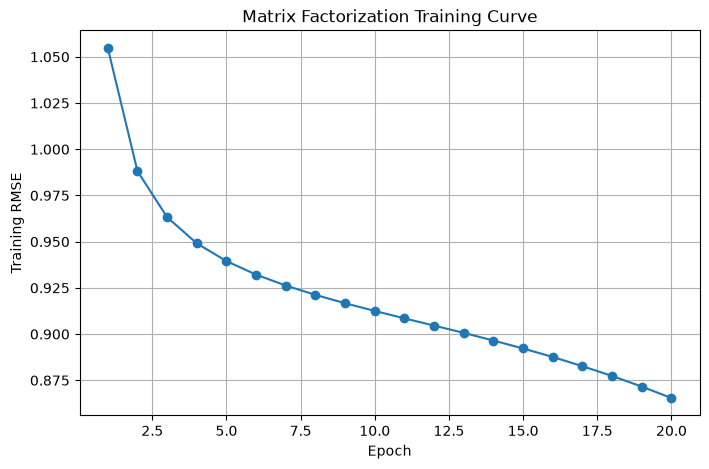

In [40]:
mf_model = MatrixFactorization(
    n_users=len(users),
    n_items=len(items),
    n_factors=20,
    learning_rate=0.005,
    reg=0.02,
    seed=SEED
)

mf_history = mf_model.fit(
    mf_train,
    epochs=20
)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(mf_history) + 1),
    mf_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training RMSE")
plt.title("Matrix Factorization Training Curve")
plt.grid(True)
plt.show()

In [41]:
def evaluate_mf(model, data):
    actual = []
    predicted = []

    for row in data.itertuples(index=False):

        pred = model.predict(
            row.user_id,
            row.item_id,
            user_to_idx,
            item_to_idx
        )

        if not np.isnan(pred):
            actual.append(row.rating)
            predicted.append(pred)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    coverage = len(predicted) / len(data)

    return rmse, mae, coverage


val_rmse, val_mae, val_coverage = evaluate_mf(
    mf_model,
    val
)

print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation Coverage: {val_coverage:.4%}")

Validation RMSE: 0.9482
Validation MAE: 0.7495
Validation Coverage: 99.8400%


In [42]:
mf_configs = [
    {"n_factors": 10, "learning_rate": 0.005, "reg": 0.02},
    {"n_factors": 20, "learning_rate": 0.005, "reg": 0.02},
    {"n_factors": 40, "learning_rate": 0.005, "reg": 0.02},
    {"n_factors": 10, "learning_rate": 0.01,  "reg": 0.02},
    {"n_factors": 20, "learning_rate": 0.01,  "reg": 0.02},
    {"n_factors": 40, "learning_rate": 0.01,  "reg": 0.02},
]

mf_tuning_results = []

for config in mf_configs:

    print("\n" + "=" * 60)
    print(config)

    model = MatrixFactorization(
        n_users=len(users),
        n_items=len(items),
        n_factors=config["n_factors"],
        learning_rate=config["learning_rate"],
        reg=config["reg"],
        seed=SEED
    )

    history = model.fit(
        mf_train,
        epochs=20,
        verbose=False
    )

    val_rmse, val_mae, coverage = evaluate_mf(
        model,
        val
    )

    mf_tuning_results.append({
        "n_factors": config["n_factors"],
        "learning_rate": config["learning_rate"],
        "reg": config["reg"],
        "epochs": 20,
        "Validation RMSE": val_rmse,
        "Validation MAE": val_mae,
        "Coverage": coverage
    })

    print(f"Validation RMSE: {val_rmse:.4f}")
    print(f"Validation MAE:  {val_mae:.4f}")
    print(f"Coverage:        {coverage:.4%}")


{'n_factors': 10, 'learning_rate': 0.005, 'reg': 0.02}
Validation RMSE: 0.9461
Validation MAE:  0.7482
Coverage:        99.8400%

{'n_factors': 20, 'learning_rate': 0.005, 'reg': 0.02}
Validation RMSE: 0.9482
Validation MAE:  0.7495
Coverage:        99.8400%

{'n_factors': 40, 'learning_rate': 0.005, 'reg': 0.02}
Validation RMSE: 0.9473
Validation MAE:  0.7485
Coverage:        99.8400%

{'n_factors': 10, 'learning_rate': 0.01, 'reg': 0.02}
Validation RMSE: 0.9420
Validation MAE:  0.7407
Coverage:        99.8400%

{'n_factors': 20, 'learning_rate': 0.01, 'reg': 0.02}
Validation RMSE: 0.9559
Validation MAE:  0.7485
Coverage:        99.8400%

{'n_factors': 40, 'learning_rate': 0.01, 'reg': 0.02}
Validation RMSE: 0.9626
Validation MAE:  0.7534
Coverage:        99.8400%


In [43]:
mf_tuning_df = pd.DataFrame(mf_tuning_results)

mf_tuning_df = mf_tuning_df.sort_values(
    "Validation RMSE"
).reset_index(drop=True)

mf_tuning_df

,n_factors,learning_rate,reg,epochs,Validation RMSE,Validation MAE,Coverage
0,10,0.010,0.02,20,0.941960,0.740693,0.9984
1,10,0.005,0.02,20,0.946089,0.748167,0.9984
2,40,0.005,0.02,20,0.947330,0.748508,0.9984
3,20,0.005,0.02,20,0.948244,0.749505,0.9984
4,20,0.010,0.02,20,0.955942,0.748517,0.9984
5,40,0.010,0.02,20,0.962557,0.753443,0.9984


In [45]:
best_mf_model = MatrixFactorization(
    n_users=len(users),
    n_items=len(items),
    n_factors=10,
    learning_rate=0.01,
    reg=0.02,
    seed=SEED
)

best_mf_history = best_mf_model.fit(
    mf_train,
    epochs=20
)

mf_test_rmse, mf_test_mae, mf_test_coverage = evaluate_mf(
    best_mf_model,
    test
)

print(f"Test RMSE: {mf_test_rmse:.4f}")
print(f"Test MAE: {mf_test_mae:.4f}")
print(f"Test Coverage: {mf_test_coverage:.4%}")



Epoch  1/20 | Train RMSE: 1.0264
Epoch  2/20 | Train RMSE: 0.9621
Epoch  3/20 | Train RMSE: 0.9434
Epoch  4/20 | Train RMSE: 0.9329
Epoch  5/20 | Train RMSE: 0.9257
Epoch  6/20 | Train RMSE: 0.9199
Epoch  7/20 | Train RMSE: 0.9144
Epoch  8/20 | Train RMSE: 0.9089
Epoch  9/20 | Train RMSE: 0.9027
Epoch 10/20 | Train RMSE: 0.8955
Epoch 11/20 | Train RMSE: 0.8873
Epoch 12/20 | Train RMSE: 0.8780
Epoch 13/20 | Train RMSE: 0.8679
Epoch 14/20 | Train RMSE: 0.8572
Epoch 15/20 | Train RMSE: 0.8464
Epoch 16/20 | Train RMSE: 0.8358
Epoch 17/20 | Train RMSE: 0.8254
Epoch 18/20 | Train RMSE: 0.8156
Epoch 19/20 | Train RMSE: 0.8062
Epoch 20/20 | Train RMSE: 0.7976
Test RMSE: 0.9349
Test MAE: 0.7318
Test Coverage: 99.8267%


In [46]:
# Final MF test results
mf_results = {
    "Model": "Matrix Factorization",
    "Factors": 10,
    "Learning Rate": 0.01,
    "Regularization": 0.02,
    "Epochs": 20,
    "Validation RMSE": 0.941960,
    "Validation MAE": 0.740693,
    "Test RMSE": mf_test_rmse,
    "Test MAE": mf_test_mae,
    "Test Coverage": mf_test_coverage
}

mf_results

{'Model': 'Matrix Factorization',
 'Factors': 10,
 'Learning Rate': 0.01,
 'Regularization': 0.02,
 'Epochs': 20,
 'Validation RMSE': 0.94196,
 'Validation MAE': 0.740693,
 'Test RMSE': np.float64(0.9349373627295703),
 'Test MAE': 0.7317711330509122,
 'Test Coverage': 0.9982666666666666}

In [47]:
final_results = pd.DataFrame([
    {
        "Model": "Item-Item CF",
        "Validation RMSE": 0.9765789429,
        "Validation MAE": 0.7605581436,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "Test Coverage": test_coverage
    },
    {
        "Model": "Matrix Factorization",
        "Validation RMSE": 0.941960,
        "Validation MAE": 0.740693,
        "Test RMSE": float(mf_test_rmse),
        "Test MAE": float(mf_test_mae),
        "Test Coverage": float(mf_test_coverage)
    }
])

final_results

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE,Test Coverage
0,Item-Item CF,0.976579,0.760558,0.967356,0.755617,0.998200
1,Matrix Factorization,0.941960,0.740693,0.934937,0.731771,0.998267


In [48]:
item_rmse = test_rmse
mf_rmse = float(mf_test_rmse)

item_mae = test_mae
mf_mae = float(mf_test_mae)

rmse_improvement = (item_rmse - mf_rmse) / item_rmse * 100
mae_improvement = (item_mae - mf_mae) / item_mae * 100

print(f"RMSE reduction: {rmse_improvement:.2f}%")
print(f"MAE reduction: {mae_improvement:.2f}%")

RMSE reduction: 3.35%
MAE reduction: 3.16%


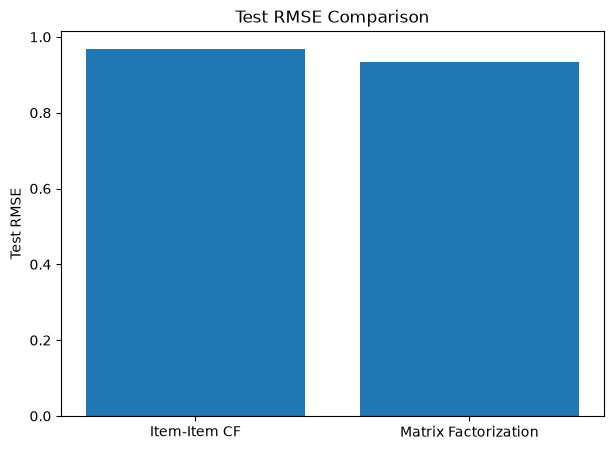

In [49]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_results["Model"],
    final_results["Test RMSE"]
)

plt.ylabel("Test RMSE")
plt.title("Test RMSE Comparison")

plt.show()

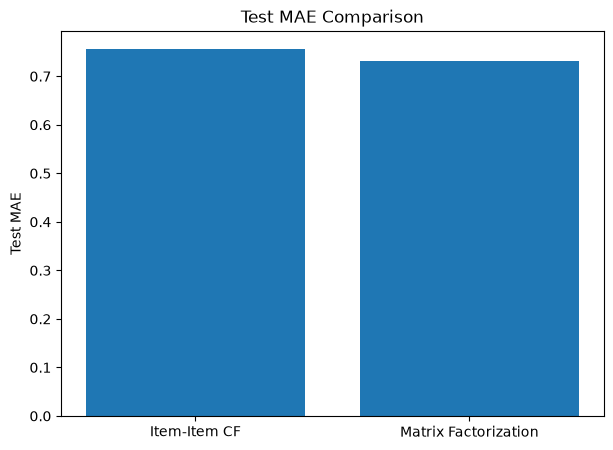

In [50]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_results["Model"],
    final_results["Test MAE"]
)

plt.ylabel("Test MAE")
plt.title("Test MAE Comparison")

plt.show()

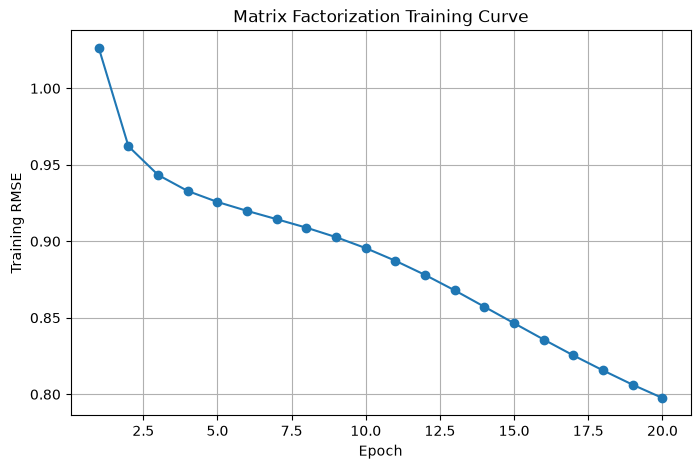

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(best_mf_history) + 1),
    best_mf_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training RMSE")
plt.title("Matrix Factorization Training Curve")
plt.grid(True)

plt.show()

In [52]:
def recommend_item_cf(
    user_id,
    user_item_matrix,
    user_to_idx,
    item_to_idx,
    idx_to_item,
    item_similarity,
    k_neighbors=10,
    n_recommendations=10
):
    if user_id not in user_to_idx:
        return []

    user_idx = user_to_idx[user_id]
    user_ratings = user_item_matrix[user_idx]

    rated_items = set(np.flatnonzero(user_ratings))

    candidate_items = [
        i for i in range(len(item_to_idx))
        if i not in rated_items
    ]

    predictions = []

    for item_idx in candidate_items:
        similarities = item_similarity[item_idx]

        rated_array = np.array(list(rated_items))

        if len(rated_array) == 0:
            continue

        sims = similarities[rated_array]

        top_k = min(k_neighbors, len(rated_array))

        top_indices = np.argsort(sims)[-top_k:]

        selected_sims = sims[top_indices]
        selected_items = rated_array[top_indices]

        denominator = np.sum(np.abs(selected_sims))

        if denominator == 0:
            continue

        pred = np.sum(
            selected_sims * user_ratings[selected_items]
        ) / denominator

        pred = np.clip(pred, 1.0, 5.0)

        predictions.append((item_idx, pred))

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return [
        (idx_to_item[item_idx], score)
        for item_idx, score in predictions[:n_recommendations]
    ]

sample_user = 196

recommendations = recommend_item_cf(
    sample_user,
    user_item_matrix,
    user_to_idx,
    item_to_idx,
    idx_to_item,
    item_similarity,
    k_neighbors=10,
    n_recommendations=10
)

recommendations

[(np.int64(1464), np.float32(4.5705876)),
 (np.int64(1306), np.float32(4.513263)),
 (np.int64(1308), np.float32(4.513263)),
 (np.int64(1309), np.float32(4.513263)),
 (np.int64(1310), np.float32(4.513263)),
 (np.int64(1275), np.float32(4.485442)),
 (np.int64(1455), np.float32(4.3800364)),
 (np.int64(1304), np.float32(4.3657455)),
 (np.int64(1449), np.float32(4.3436165)),
 (np.int64(1397), np.float32(4.2654614))]

In [53]:
movie_columns = [
    "item_id",
    "title",
    "release_date",
    "video_release_date",
    "imdb_url",
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western"
]

movies = pd.read_csv(
    "data/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    names=movie_columns,
    usecols=["item_id", "title"]
)

movie_lookup = dict(
    zip(movies["item_id"], movies["title"])
)

recommendation_table = pd.DataFrame(
    [
        {
            "item_id": item_id,
            "title": movie_lookup.get(item_id, "Unknown"),
            "predicted_rating": score
        }
        for item_id, score in recommendations
    ]
)

recommendation_table

test_known = test[
    test["user_id"].isin(user_to_idx) &
    test["item_id"].isin(item_to_idx)
]

val_known = val[
    val["user_id"].isin(user_to_idx) &
    val["item_id"].isin(item_to_idx)
]

print("Validation total:", len(val))
print("Validation known:", len(val_known))
print("Validation excluded:", len(val) - len(val_known))

print("\nTest total:", len(test))
print("Test known:", len(test_known))
print("Test excluded:", len(test) - len(test_known))

Validation total: 15001
Validation known: 14977
Validation excluded: 24

Test total: 15000
Test known: 14974
Test excluded: 26


In [54]:
final_results = pd.DataFrame([
    {
        "Model": "Item-Item CF",
        "Validation RMSE": 0.9765789429,
        "Validation MAE": 0.7605581436,
        "Test RMSE": float(test_rmse),
        "Test MAE": float(test_mae),
        "Test Coverage": float(test_coverage)
    },
    {
        "Model": "Matrix Factorization",
        "Validation RMSE": 0.941960,
        "Validation MAE": 0.740693,
        "Test RMSE": float(mf_test_rmse),
        "Test MAE": float(mf_test_mae),
        "Test Coverage": float(mf_test_coverage)
    }
])

final_results

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE,Test Coverage
0,Item-Item CF,0.976579,0.760558,0.967356,0.755617,0.998200
1,Matrix Factorization,0.941960,0.740693,0.934937,0.731771,0.998267


In [55]:
rmse_reduction = (
    (test_rmse - mf_test_rmse) / test_rmse
) * 100

mae_reduction = (
    (test_mae - mf_test_mae) / test_mae
) * 100

print(f"RMSE reduction: {rmse_reduction:.2f}%")
print(f"MAE reduction: {mae_reduction:.2f}%")

RMSE reduction: 3.35%
MAE reduction: 3.16%


In [56]:
def recommend_mf(
    user_id,
    model,
    user_item_matrix,
    user_to_idx,
    item_to_idx,
    idx_to_item,
    n_recommendations=10
):
    if user_id not in user_to_idx:
        return []

    user_idx = user_to_idx[user_id]

    rated_items = set(
        np.flatnonzero(user_item_matrix[user_idx])
    )

    recommendations = []

    for item_idx in range(len(item_to_idx)):

        if item_idx in rated_items:
            continue

        prediction = model.predict_idx(
            user_idx,
            item_idx
        )

        prediction = np.clip(prediction, 1.0, 5.0)

        recommendations.append(
            (idx_to_item[item_idx], prediction)
        )

    recommendations.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return recommendations[:n_recommendations]


sample_user = 196

mf_recommendations = recommend_mf(
    sample_user,
    best_mf_model,
    user_item_matrix,
    user_to_idx,
    item_to_idx,
    idx_to_item,
    n_recommendations=10
)

mf_recommendations

[(np.int64(169), np.float64(4.597258591333569)),
 (np.int64(483), np.float64(4.57403658670677)),
 (np.int64(64), np.float64(4.441970238273085)),
 (np.int64(185), np.float64(4.435513207007751)),
 (np.int64(318), np.float64(4.404009300888725)),
 (np.int64(114), np.float64(4.3876489027695)),
 (np.int64(657), np.float64(4.373076547747729)),
 (np.int64(98), np.float64(4.371075454245864)),
 (np.int64(1449), np.float64(4.368946201792857)),
 (np.int64(923), np.float64(4.354146209672209))]

In [57]:
mf_recommendation_table = pd.DataFrame(
    [
        {
            "item_id": item_id,
            "title": movie_lookup.get(item_id, "Unknown"),
            "predicted_rating": score
        }
        for item_id, score in mf_recommendations
    ]
)

mf_recommendation_table

,item_id,title,predicted_rating
0,169,"Wrong Trousers, The (1993)",4.597259
1,483,Casablanca (1942),4.574037
2,64,"Shawshank Redemption, The (1994)",4.441970
3,185,Psycho (1960),4.435513
4,318,Schindler's List (1993),4.404009
5,114,Wallace & Gromit: The Best of Aardman Animatio...,4.387649
6,657,"Manchurian Candidate, The (1962)",4.373077
7,98,"Silence of the Lambs, The (1991)",4.371075
8,1449,Pather Panchali (1955),4.368946
9,923,Raise the Red Lantern (1991),4.354146


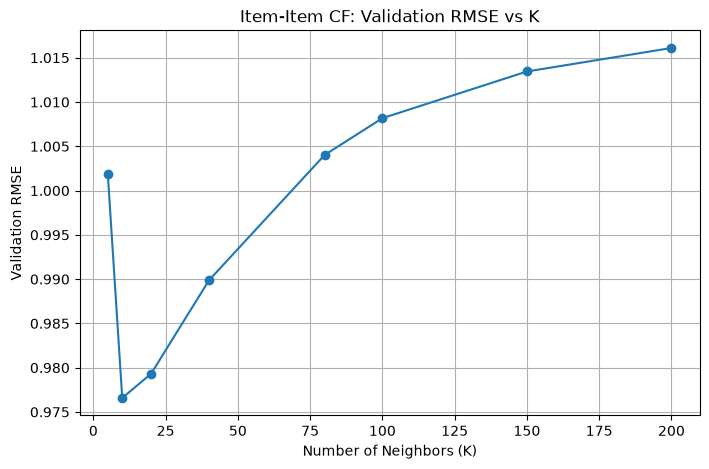

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    cf_results_df["k"],
    cf_results_df["RMSE"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Validation RMSE")
plt.title("Item-Item CF: Validation RMSE vs K")
plt.grid(True)

plt.show()

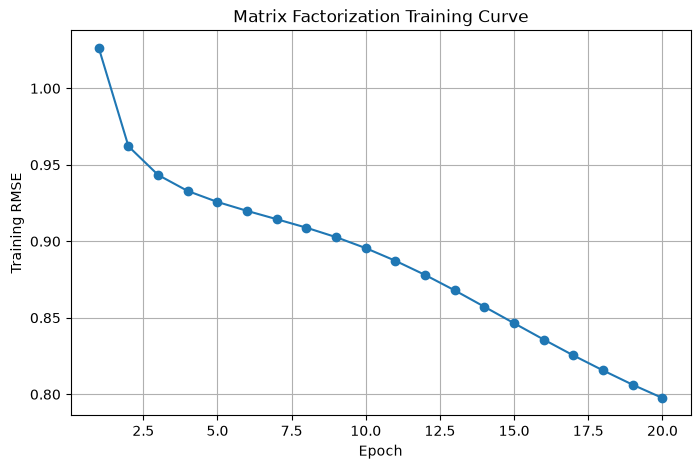

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(best_mf_history) + 1),
    best_mf_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training RMSE")
plt.title("Matrix Factorization Training Curve")
plt.grid(True)

plt.show()

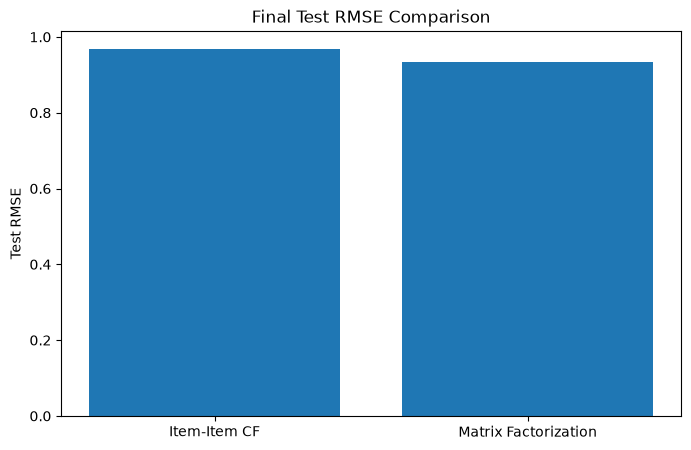

In [60]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_results["Model"],
    final_results["Test RMSE"]
)

plt.ylabel("Test RMSE")
plt.title("Final Test RMSE Comparison")

plt.show()

In [61]:
final_results

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE,Test Coverage
0,Item-Item CF,0.976579,0.760558,0.967356,0.755617,0.998200
1,Matrix Factorization,0.941960,0.740693,0.934937,0.731771,0.998267


In [ ]:
## Final Results

#The two collaborative filtering approaches were evaluated using the same
#train/validation/test split. Item-Item CF was tuned using the validation set
#and Matrix Factorization hyperparameters were also selected using validation
#performance. The test set was used only for the final evaluation.



## Conclusion

This task compared a memory-based collaborative filtering method,
Item-Item Collaborative Filtering, with a model-based Matrix
Factorization approach using the MovieLens 100K dataset.

The Item-Item CF model achieved its best validation performance with
K = 10 neighbors. Its final test RMSE was 0.9674 and test MAE was 0.7556.

Matrix Factorization was tuned using the validation set. The selected
configuration used 10 latent factors, a learning rate of 0.01, a
regularization coefficient of 0.02, and 20 training epochs. It achieved
a test RMSE of approximately 0.9349 and a test MAE of approximately
0.7318.

For this particular dataset, split, and experimental configuration,
Matrix Factorization produced lower test RMSE and MAE than Item-Item CF.

Memory-based collaborative filtering is useful when direct item or user
similarities are desirable and the interaction history can provide
meaningful neighborhoods. Model-based matrix factorization is useful when
learning latent representations can capture patterns that are not directly
represented by nearest-neighbor similarity.

The experiment also demonstrates the cold-start limitation of collaborative
filtering: a small number of validation and test interactions involved
items that were not observed in the training data and therefore could not
be predicted by the trained models.